In [65]:
import os
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('/media/carsen/ssd1/github/oneshot')
from utils import data
mouse_ids = [7,8,10,11,12]
save_path = './result'
server_path = '/home/carsen/dm11_cluster/fengtongd/Desktop/github/oneshot'

In [66]:
mouse_id = 8
res_dict = np.load(os.path.join(save_path, f'{data.mouse_names[mouse_id]}_{data.exp_date[mouse_id]}_fullmodel_result.npz'), allow_pickle=True)
fev = res_dict['FEV'].astype(float)
rf_size = res_dict['rf_size_visual'].astype(float)
feve = res_dict['FEVE_fullmodel'].astype(float)
fecv = res_dict['FECV_model'].astype(float)
fecv[np.isnan(fecv)] = 0
ilayer = res_dict['ilayer'].astype(int)
iarea = res_dict['iarea'].astype(int)
gabor_mf = res_dict['gabor_mf'].astype(float)
gabor_msigma = res_dict['gabor_msigma'].astype(float)
gabor_mtheta = res_dict['gabor_mtheta'].astype(float)
depth_feve = res_dict['FEVE_all_depth'].astype(float) # (n_depth, n_neurons)

In [67]:
ineur = res_dict['ineur'].astype(int)
print(len(ineur), ineur.min(), ineur.max())

fev_all = res_dict['FEV_all'].astype(float) # (n_neurons, n_models)

1655 4 5176


In [68]:

NN_valid = data.NNs_valid[mouse_id]
ineurons = np.arange(NN_valid)
np.random.seed(42)
ineurons = np.random.choice(ineurons, 100, replace=False)

isort_neurons = np.argsort(fev_all)[::-1]
ineurons = isort_neurons[ineurons]

In [69]:
iarea_all = np.ones(len(fev_all), dtype=int) * np.nan
iarea_all[ineur] = iarea
iarea = iarea_all[ineurons]
print(iarea)

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.
 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.
 0. 0. 0. 0.]


In [70]:
print(ineurons)

[3955  562 1889 3466  188 4259 3121  271 3194 1675 3122 4129 3333  592
 1457 1892 4579  109 1857 4076   55 3198  953 3953 3158   47 4561 1075
 4711 4568 4146 1866 3786   71 3041 2922 3077 1659 1061  102 1740 2200
 1746 4131 2172 3948 2188 2091 4769 2434 4934 4589 1467  740  907 1546
 2374 3945 4368   13 4692  520 3267 2927 2228 4827 4885  117 3209  323
 4586  526 3047 2983  360 1487 4776 4640 3917 2284   54 2473  433 2865
 4515 4051 1484  976 4464 3205 4234 3992  496  912 4651 1453 1906 1900
 5027 4458]


In [71]:
op_list = ['conv2_1x1', 'conv2_spatial', 'conv2_relu', 'Wxy', 'elu']

import torch
device = torch.device('cpu')
# FECV
save_path = './result'
fname = 'text16_%s_%s.npz'%(data.db[mouse_id]['mname'], data.db[mouse_id]['datexp'])
dat = np.load(os.path.join('../data', fname), allow_pickle=True)

txt16_spks_train = dat['sp'].T
# txt16_istim_train = dat['istim'].astype(int)
txt16_labels_train = dat['labels']
txt16_istim_train = dat['istim'].astype(int)


print('txt16_spks_train shape:', txt16_spks_train.shape)
print('txt16_labels_train shape:', txt16_labels_train.shape)
print('txt16_istim_train shape:', txt16_istim_train.shape)


txt16_spks_test_ori = dat['ss_all'] # each image has different reps
print('txt16_spks_test shape (nstim, nrep, nneuron):', txt16_spks_test_ori.shape)
# txt16_istim_test_ori = dat['ss_istim'].astype(int)
txt16_labels_test_ori = dat['ss_labels']
txt16_istim_test_ori = dat['ss_istim'].astype(int)

txt16_spks_test = []
txt16_labels_test = []
txt16_istim_test = []

for i in range(txt16_spks_test_ori.shape[0]):
    nrep = txt16_spks_test_ori[i].shape[0]
    txt16_spks_test.append(txt16_spks_test_ori[i])
    txt16_labels_test.append(np.repeat(txt16_labels_test_ori[i], nrep))
    txt16_istim_test.append(np.repeat(txt16_istim_test_ori[i], nrep))


txt16_spks_test = np.vstack(txt16_spks_test)
txt16_labels_test = np.hstack(txt16_labels_test)
txt16_istim_test = np.hstack(txt16_istim_test)

print('txt16_spks_test shape:', txt16_spks_test.shape)
print('txt16_labels_test shape:', txt16_labels_test.shape)
print('txt16_istim_test shape:', txt16_istim_test.shape)

txt16_spks = np.vstack((txt16_spks_train, txt16_spks_test)).astype(np.float32)
txt16_labels = np.hstack((txt16_labels_train, txt16_labels_test)).astype(int)
txt16_istim = np.hstack((txt16_istim_train, txt16_istim_test)) - 32

print('txt16_spks shape:', txt16_spks.shape)
print('txt16_labels shape:', txt16_labels.shape)
print('txt16_istim shape:', txt16_istim.shape)

from scipy.stats import zscore
txt16_spks = zscore(txt16_spks, axis=0)

txt16_spks_train shape: (3618, 5196)
txt16_labels_train shape: (3618,)
txt16_istim_train shape: (3618,)
txt16_spks_test shape (nstim, nrep, nneuron): (764,)
txt16_spks_test shape: (5627, 5196)
txt16_labels_test shape: (5627,)
txt16_istim_test shape: (5627,)
txt16_spks shape: (9245, 5196)
txt16_labels shape: (9245,)
txt16_istim shape: (9245,)


In [72]:
# load txt16 images
if mouse_id in [10, 11]: crop=False
else: crop=True

data_path = '/home/carsen/dm11_pachitariu/data/STIM/'
img = data.load_images(data_path, file=os.path.join(data_path, 'nat60k_text16.mat'), normalize=False, crop=crop)
# img = data.load_images_mat(img_root, file='nat60k_text16.mat', downsample=1, normalize=True, crop=False, origin=True)[0]
print('img: ', img.shape, img.min(), img.max(), img.dtype)

txt16_img = img[txt16_istim]
print(txt16_img.shape, txt16_img.max(), txt16_img.min())

# zscore txt16_imgs
img_mean = txt16_img.mean()
img_std = txt16_img.std()
txt16_img_zscore = (txt16_img - img_mean) / img_std
print(txt16_img_zscore.shape, txt16_img_zscore.max(), txt16_img_zscore.min())
txt16_img_zscore = torch.from_numpy(txt16_img_zscore).to(device).unsqueeze(1)
print(txt16_img_zscore.shape)

raw image shape:  (68000, 66, 264)
cropped image shape:  (68000, 66, 130)
image mean:  126.71192
image std:  61.422768
img:  (68000, 66, 130) 0.0 255.0 float32
(9245, 66, 130) 255.0 0.0
(9245, 66, 130) 2.1026986 -2.0629814
torch.Size([9245, 1, 66, 130])


In [ ]:
# for ineuron in valid_ineurons[1:5]:
from utils import model_builder, metrics

# build model
seed = 1
nlayers = 2
nconv1 = 16
nconv2 = 64
wc_coef = 0.2
hs_readout = 0.03
depth_separable = True
pool = True
clamp = True

for ineuron in ineurons:
    ineur = [ineuron]

    save_path = './outputs/catvar'
    save_file_name = f'{data.mouse_names[mouse_id]}_minimodel_{nconv1}_{nconv2}_pairwise_catvar_neuron{ineur[0]}_result.npz'

    if os.path.exists(os.path.join(save_path, data.mouse_names[mouse_id], save_file_name)):
        print('already done:', os.path.join(save_path, data.mouse_names[mouse_id], save_file_name))
        continue

    from utils import model_builder
    model, in_channels = model_builder.build_model(NN=1, n_layers=nlayers, n_conv=nconv1, n_conv_mid=nconv2, pool=pool, depth_separable=depth_separable, Wc_coef=wc_coef)
    model_name = model_builder.create_model_name(data.mouse_names[mouse_id], data.exp_date[mouse_id], ineuron=ineur[0], n_layers=nlayers, in_channels=in_channels, clamp=clamp, seed=seed,hs_readout=hs_readout)

    weight_path = os.path.join(server_path, 'weights', 'minimodel', data.mouse_names[mouse_id])
    model_path = os.path.join(weight_path, model_name)
    print('model path: ', model_path)
    model.load_state_dict(torch.load(model_path))
    print('loaded model', model_path)
    model = model.to(device)

    data_dict = {}

    Wc = model.readout.Wc.cpu().detach().numpy().squeeze()
    valid_channels = np.where(np.abs(Wc)>0.01)[0]

    # get conv2 features and catvar
    model.eval()
    conv1_pool_fvs = model.core.features.layer0(txt16_img_zscore)
    print('after conv1_pool: ', conv1_pool_fvs.shape, conv1_pool_fvs.max(), conv1_pool_fvs.min())

    conv2_1x1_fvs = model.core.features.layer1.ds_conv.in_depth_conv(conv1_pool_fvs)
    print('after conv2_1x1: ', conv2_1x1_fvs.shape, conv2_1x1_fvs.max(), conv2_1x1_fvs.min())

    conv2_spatial_fvs = model.core.features.layer1.ds_conv.spatial_conv(conv2_1x1_fvs)
    print('after conv2_spatial: ', conv2_spatial_fvs.shape, conv2_spatial_fvs.max(), conv2_spatial_fvs.min())

    conv2_bn_fvs = model.core.features.layer1.norm(conv2_spatial_fvs)
    print('after conv2_bn: ', conv2_bn_fvs.shape, conv2_bn_fvs.max(), conv2_bn_fvs.min())

    conv2_relu_fvs = model.core.features.layer1.activation(conv2_bn_fvs)
    print('after conv2_relu: ', conv2_relu_fvs.shape, conv2_relu_fvs.max(), conv2_relu_fvs.min())

    wxy_fvs = torch.einsum('iry, irx, ncyx -> ncr', model.readout.Wy, model.readout.Wx, conv2_relu_fvs)
    print('after wxy: ', wxy_fvs.shape, wxy_fvs.max(), wxy_fvs.min())
    data_dict['channel_activities'] = wxy_fvs.cpu().detach().numpy().squeeze()

    wc_fvs = torch.einsum('nrc, ncr -> nr', model.readout.Wc, wxy_fvs)
    print('after wc: ', wc_fvs.shape, wc_fvs.max(), wc_fvs.min())

    elu_fvs = model.readout.activation(wc_fvs+model.readout.bias)
    print('after elu: ', elu_fvs.shape, elu_fvs.max(), elu_fvs.min())


    model_fvs_all = [conv2_1x1_fvs.cpu().detach().numpy()[:, valid_channels], conv2_spatial_fvs.cpu().detach().numpy()[:, valid_channels], conv2_relu_fvs.cpu().detach().numpy()[:, valid_channels], \
                    wxy_fvs.cpu().detach().numpy()[:, valid_channels], elu_fvs.cpu().detach().numpy()]

    catvar_all = np.zeros(len(op_list))
    for i in range(len(op_list)):
        fv = model_fvs_all[i].reshape(model_fvs_all[i].shape[0], -1) # (nstim, nfeatures)
        if len(fv.shape) == 1:
            fv = fv[:, np.newaxis]
        cat_var = metrics.category_variance_pairwise(fv.T, txt16_labels)
        catvar_all[i] = np.nanmean(cat_var)

    data_dict['catvar'] = catvar_all
    data_dict['op_names'] = op_list
    pred = model(txt16_img_zscore)
    data_dict['pred'] = pred.cpu().detach().numpy().squeeze()
    data_dict['wc'] = Wc

    np.savez(os.path.join(save_path, data.mouse_names[mouse_id], save_file_name), **data_dict)

already done: ./outputs/catvar/FX43/FX43_minimodel_16_64_pairwise_catvar_neuron3955_result.npz
input shape of readout:  (64, 33, 65)
model name:  FX43_012425_2layer_16_64_clamp_sensorium_depthsep_pool_nneurons_562_hs3e-02.pt
model path:  /home/carsen/dm11_cluster/fengtongd/Desktop/github/oneshot/weights/minimodel/FX43/FX43_012425_2layer_16_64_clamp_sensorium_depthsep_pool_nneurons_562_hs3e-02.pt
loaded model /home/carsen/dm11_cluster/fengtongd/Desktop/github/oneshot/weights/minimodel/FX43/FX43_012425_2layer_16_64_clamp_sensorium_depthsep_pool_nneurons_562_hs3e-02.pt
after conv1_pool:  torch.Size([9245, 16, 33, 65]) tensor(2.3649, grad_fn=<MaxBackward1>) tensor(0., grad_fn=<MinBackward1>)
after conv2_1x1:  torch.Size([9245, 64, 33, 65]) tensor(0.3759, grad_fn=<MaxBackward1>) tensor(-0.5122, grad_fn=<MinBackward1>)
after conv2_spatial:  torch.Size([9245, 64, 33, 65]) tensor(0.3824, grad_fn=<MaxBackward1>) tensor(-0.6789, grad_fn=<MinBackward1>)
after conv2_bn:  torch.Size([9245, 64, 33, 

In [ ]:
data_path = './outputs/catvar'
op_list = ['conv2_1x1', 'conv2_spatial', 'conv2_relu', 'Wxy', 'elu']

nneurons = len(ineurons)
catvar_all = np.zeros((nneurons, len(op_list)))
channel_activities_all = np.zeros((nneurons, 8110, 64))
wc_all = np.zeros((nneurons, 64))
# ineuron = valid_ineurons[0]
for i, ineuron in enumerate(ineurons):
    ineur = [ineuron]
    file_name = f'{data.mouse_names[mouse_id]}_minimodel_16_64_pairwise_catvar_neuron{ineur[0]}_result.npz'
    file_path = os.path.join(data_path, data.mouse_names[mouse_id], file_name)
    dat = np.load(file_path, allow_pickle=True)
    channel_activities = dat['channel_activities']
    op_names = dat['op_names']
    catvar = dat['catvar']
    catvar_all[i] = catvar
    channel_activities_all[i] = channel_activities
    wc_all[i] = dat['wc']

In [ ]:
# correlaton of positive channels
print(channel_activities_all.shape) # nneuron, nstim, nchannel
print(wc_all.shape) # nneuron, nchannel

import numpy as np
from scipy.stats import pearsonr

# Example matrices
# channel_activities_all: (nneuron, nstim, nchannel)
# wc_all: (nneuron, nchannel)

# Initialize list to store mean correlations for each neuron
mean_correlations = []

# Loop through each neuron
for neuron_idx in range(channel_activities_all.shape[0]):
    # Get the weights and channel activities for the current neuron
    weights = wc_all[neuron_idx]
    activities = channel_activities_all[neuron_idx]
    
    # Get the indices of channels with positive weights
    positive_indices = np.where(weights > 0.01)[0]
    
    if len(positive_indices) > 1:
        # Calculate correlations between channels with positive weights
        correlations = []
        for i in range(len(positive_indices)):
            for j in range(i + 1, len(positive_indices)):
                idx1, idx2 = positive_indices[i], positive_indices[j]
                corr, _ = pearsonr(activities[:, idx1], activities[:, idx2])
                correlations.append(corr)
        
        # Calculate the mean correlation for the current neuron
        mean_correlation = np.mean(correlations)
    else:
        # If there are less than 2 channels with positive weights, correlation is not defined
        mean_correlation = np.nan
    
    # Append the mean correlation to the list
    mean_correlations.append(mean_correlation)

# Convert the list to a numpy array for easier handling
mean_correlations = np.array(mean_correlations)

print(len(mean_correlations))

(100, 8110, 64)
(100, 64)
100


In [ ]:
fecv.shape

(2068,)

In [ ]:
ineur = res_dict['ineur'].astype(int)
print(len(ineur), ineur.min(), ineur.max())

fecv_all = np.ones(len(fev_all)) * np.nan
fecv_all[ineur] = fecv
fecv = fecv_all[ineurons]

2068 3 5364


(100, 5)
100
r: -0.381481733707476 p: 0.02848507128054498


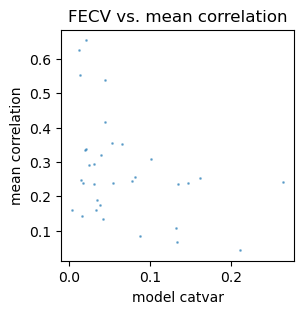

In [ ]:
print(catvar_all.shape)
print(len(mean_correlations))

xplot = fecv[iarea==0]
yplot = mean_correlations[iarea==0]
fig, ax = plt.subplots(1, 1, figsize=(3,3))
ax.scatter(xplot, yplot, s=1, alpha=0.5)
ax.set_xlabel('model catvar')
ax.set_ylabel('mean correlation')
ax.set_title('FECV vs. mean correlation')
r, p = pearsonr(xplot, yplot)
print('r:', r, 'p:', p)

In [ ]:
print(np.mean(fecv[iarea==0]), np.mean(mean_correlations[iarea==0]))
print(np.mean(fecv[iarea==1]), np.mean(mean_correlations[iarea==1]))

0.0376796008193386 0.20612621324052818
0.06713582797921532 0.27521349688728236


In [ ]:
d

In [ ]:
rfsize_all = []
fecv_all = []
layers_all = []
areas_all = []
feve_all = []
fev_all = []
mf_all = []
msigma_all = []
mtheta_all = []
planes_all = []
all_depth_feve = []
area_names = ['V1', 'medial']
layer_names = ['layer 1', 'layer 2/3']
mouse_id_all = []
for i, mouse_id in enumerate(mouse_ids):
    res_dict = np.load(os.path.join(save_path, f'{data.mouse_names[mouse_id]}_{data.exp_date[mouse_id]}_fullmodel_result.npz'), allow_pickle=True)
    fev = res_dict['FEV'].astype(float)
    rf_size = res_dict['rf_size_visual'].astype(float)
    feve = res_dict['FEVE_fullmodel'].astype(float)
    fecv = res_dict['FECV_model'].astype(float)
    fecv[np.isnan(fecv)] = 0
    ilayer = res_dict['ilayer'].astype(int)
    iarea = res_dict['iarea'].astype(int)
    gabor_mf = res_dict['gabor_mf'].astype(float)
    gabor_msigma = res_dict['gabor_msigma'].astype(float)
    gabor_mtheta = res_dict['gabor_mtheta'].astype(float)
    depth_feve = res_dict['FEVE_all_depth'].astype(float) # (n_depth, n_neurons)
    all_depth_feve.append(depth_feve)
    rfsize_all.append(rf_size)
    fecv_all.append(fecv)
    feve_all.append(feve)
    fev_all.append(fev)
    layers_all.append(ilayer)
    areas_all.append(iarea)
    mf_all.append(gabor_mf)
    msigma_all.append(gabor_msigma)
    mtheta_all.append(gabor_mtheta)
    mouse_id_all.append(np.ones_like(rf_size)*mouse_id)
    print(len(rf_size))
rfsize_all = np.concatenate(rfsize_all)
fecv_all = np.concatenate(fecv_all)
feve_all = np.concatenate(feve_all)
fev_all = np.concatenate(fev_all)
layers_all = np.concatenate(layers_all)
areas_all = np.concatenate(areas_all)
mf_all = np.concatenate(mf_all)
msigma_all = np.concatenate(msigma_all)
mtheta_all = np.concatenate(mtheta_all)
all_depth_feve = np.concatenate(all_depth_feve, axis=1) # (n_depth, n_neurons_total)
mouse_id_all = np.concatenate(mouse_id_all)

print(f'rfsize_all: {rfsize_all.shape}, fecv_all: {fecv_all.shape}, feve_all: {feve_all.shape}, fev_all: {fev_all.shape}, layers_all: {layers_all.shape}, areas_all: {areas_all.shape}, mf_all: {mf_all.shape}, msigma_all: {msigma_all.shape}, mtheta_all: {mtheta_all.shape}')

2068
1655
886
306
1681
rfsize_all: (6596,), fecv_all: (6596,), feve_all: (6596,), fev_all: (6596,), layers_all: (6596,), areas_all: (6596,), mf_all: (6596,), msigma_all: (6596,), mtheta_all: (6596,)


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


paired t-test between areas, t=-5.002087131328576, p=0.007479383546903214


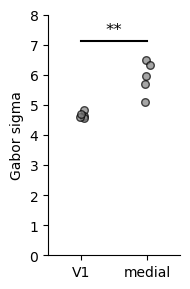

In [ ]:
# plot the sigma 
nmouse = len(mouse_ids)
varplot = np.zeros((nmouse, 2)) # mouse, area, layer
for i, mouse_id in enumerate(mouse_ids):
    for iarea in range(2):
        select = (mouse_id_all==mouse_id) & (areas_all==iarea)
        varplot[i, iarea] = np.nanmean(msigma_all[select])

fig, ax = plt.subplots(figsize=(2,3))
# scatter plot of each mouse, xaxies is V1 and medial, layer is with different color with a small shift in x axis
depth_colors = ['lightgray', 'black']
for iarea in range(2):
    x = np.ones(nmouse)*iarea + (np.random.rand(nmouse)-0.5)*0.1
    ax.scatter(x, varplot[:, iarea], color='gray', s=30, alpha=0.7, edgecolors='black')
# stats of difference between areas with paired t-test
from scipy import stats
t, p = stats.ttest_rel(varplot[:,0], varplot[:,1])
print(f'paired t-test between areas, t={t}, p={p}')
# plot the stars for significance based on p value
if p < 0.001:
    star = '***'
elif p < 0.01:
    star = '**'
elif p < 0.05:
    star = '*'
else:
    star = 'n.s.'
ymax = np.nanmax(varplot)*1.1
ax.plot([0,1], [ymax, ymax], color='black')
ax.text(0.5, ymax*1.02, star, ha='center', va='bottom', color='black', fontsize=12)

ax.set_xticks([0,1])
ax.set_xticklabels(area_names)
ax.set_ylabel('Gabor sigma')
ax.legend(loc='lower right', frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim([-0.5, 1.5])
ax.set_ylim([0, 8])
fig.tight_layout()

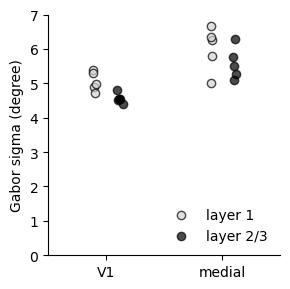

In [ ]:
# plot the sigma 
nmouse = len(mouse_ids)
varplot = np.zeros((nmouse, 2, 2)) # mouse, area, layer
for i, mouse_id in enumerate(mouse_ids):
    for iarea in range(2):
        for ilayer in range(2):
            select = (mouse_id_all==mouse_id) & (areas_all==iarea) & (layers_all==ilayer+1)
            varplot[i, iarea, ilayer] = np.nanmean(msigma_all[select])

fig, ax = plt.subplots(figsize=(3,3))
# scatter plot of each mouse, xaxies is V1 and medial, layer is with different color with a small shift in x axis
depth_colors = ['lightgray', 'black']
for ilayer in range(2):
    for iarea in range(2):
        ax.scatter(np.ones(nmouse)*iarea + (ilayer-0.5)*0.2 + np.random.randn(nmouse)*0.02, varplot[:, iarea, ilayer], color=depth_colors[ilayer], alpha=0.7, label=layer_names[ilayer] if iarea==0 else "", edgecolor='black')
        # plot the median
        # ax.scatter(iarea + (ilayer-0.5)*0.1, np.nanmedian(varplot[:, iarea, ilayer]), color=depth_colors[ilayer], s=100, edgecolor='black', marker='D')
ax.set_xticks([0,1])
ax.set_xticklabels(area_names)
ax.set_ylabel('Gabor sigma')
ax.legend(loc='lower right', frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim([-0.5, 1.5])
ax.set_ylim([0, 7])
fig.tight_layout()

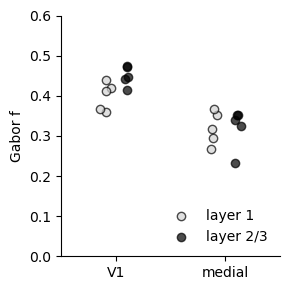

In [ ]:
# plot the f
nmouse = len(mouse_ids)
varplot = np.zeros((nmouse, 2, 2)) # mouse, area, layer
for i, mouse_id in enumerate(mouse_ids):
    for iarea in range(2):
        for ilayer in range(2):
            select = (mouse_id_all==mouse_id) & (areas_all==iarea) & (layers_all==ilayer+1)
            varplot[i, iarea, ilayer] = np.nanmean(mf_all[select])

fig, ax = plt.subplots(figsize=(3,3))
# scatter plot of each mouse, xaxies is V1 and medial, layer is with different color with a small shift in x axis
depth_colors = ['lightgray', 'black']
for ilayer in range(2):
    for iarea in range(2):
        ax.scatter(np.ones(nmouse)*iarea + (ilayer-0.5)*0.2 + np.random.randn(nmouse)*0.02, varplot[:, iarea, ilayer], color=depth_colors[ilayer], alpha=0.7, label=layer_names[ilayer] if iarea==0 else "", edgecolor='black')
        # plot the median
        # ax.scatter(iarea + (ilayer-0.5)*0.1, np.nanmedian(varplot[:, iarea, ilayer]), color=depth_colors[ilayer], s=100, edgecolor='black', marker='D')
ax.set_xticks([0,1])
ax.set_xticklabels(area_names)
ax.set_ylabel('Gabor f')
ax.legend(loc='lower right', frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim([-0.5, 1.5])
ax.set_ylim([0, 0.6])
fig.tight_layout()

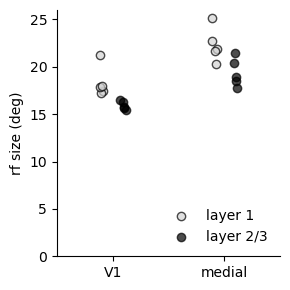

In [ ]:
# plot the f
nmouse = len(mouse_ids)
varplot = np.zeros((nmouse, 2, 2)) # mouse, area, layer
for i, mouse_id in enumerate(mouse_ids):
    for iarea in range(2):
        for ilayer in range(2):
            select = (mouse_id_all==mouse_id) & (areas_all==iarea) & (layers_all==ilayer+1)
            varplot[i, iarea, ilayer] = np.nanmean(rfsize_all[select])

fig, ax = plt.subplots(figsize=(3,3))
# scatter plot of each mouse, xaxies is V1 and medial, layer is with different color with a small shift in x axis
depth_colors = ['lightgray', 'black']
for ilayer in range(2):
    for iarea in range(2):
        ax.scatter(np.ones(nmouse)*iarea + (ilayer-0.5)*0.2 + np.random.randn(nmouse)*0.02, varplot[:, iarea, ilayer], color=depth_colors[ilayer], alpha=0.7, label=layer_names[ilayer] if iarea==0 else "", edgecolor='black')
        # plot the median
        # ax.scatter(iarea + (ilayer-0.5)*0.1, np.nanmedian(varplot[:, iarea, ilayer]), color=depth_colors[ilayer], s=100, edgecolor='black', marker='D')
ax.set_xticks([0,1])
ax.set_xticklabels(area_names)
ax.set_ylabel('rf size (deg)')
ax.legend(loc='lower right', frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim([-0.5, 1.5])
ax.set_ylim([0, 26])
fig.tight_layout()

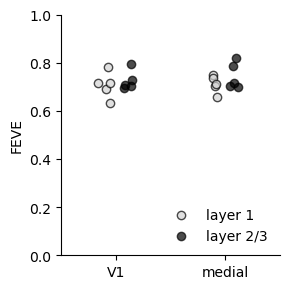

In [ ]:
# plot the f
nmouse = len(mouse_ids)
varplot = np.zeros((nmouse, 2, 2)) # mouse, area, layer
for i, mouse_id in enumerate(mouse_ids):
    for iarea in range(2):
        for ilayer in range(2):
            select = (mouse_id_all==mouse_id) & (areas_all==iarea) & (layers_all==ilayer+1)
            varplot[i, iarea, ilayer] = np.nanmean(feve_all[select])

fig, ax = plt.subplots(figsize=(3,3))
# scatter plot of each mouse, xaxies is V1 and medial, layer is with different color with a small shift in x axis
depth_colors = ['lightgray', 'black']
for ilayer in range(2):
    for iarea in range(2):
        ax.scatter(np.ones(nmouse)*iarea + (ilayer-0.5)*0.2 + np.random.randn(nmouse)*0.02, varplot[:, iarea, ilayer], color=depth_colors[ilayer], alpha=0.7, label=layer_names[ilayer] if iarea==0 else "", edgecolor='black')
        # plot the median
        # ax.scatter(iarea + (ilayer-0.5)*0.1, np.nanmedian(varplot[:, iarea, ilayer]), color=depth_colors[ilayer], s=100, edgecolor='black', marker='D')
ax.set_xticks([0,1])
ax.set_xticklabels(area_names)
ax.set_ylabel('FEVE')
ax.legend(loc='lower right', frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim([-0.5, 1.5])
ax.set_ylim([0, 1])
fig.tight_layout()

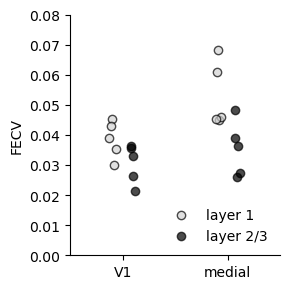

In [ ]:
# plot the f
nmouse = len(mouse_ids)
varplot = np.zeros((nmouse, 2, 2)) # mouse, area, layer
for i, mouse_id in enumerate(mouse_ids):
    for iarea in range(2):
        for ilayer in range(2):
            select = (mouse_id_all==mouse_id) & (areas_all==iarea) & (layers_all==ilayer+1)
            varplot[i, iarea, ilayer] = np.nanmean(fecv_all[select])

fig, ax = plt.subplots(figsize=(3,3))
# scatter plot of each mouse, xaxies is V1 and medial, layer is with different color with a small shift in x axis
depth_colors = ['lightgray', 'black']
for ilayer in range(2):
    for iarea in range(2):
        ax.scatter(np.ones(nmouse)*iarea + (ilayer-0.5)*0.2 + np.random.randn(nmouse)*0.02, varplot[:, iarea, ilayer], color=depth_colors[ilayer], alpha=0.7, label=layer_names[ilayer] if iarea==0 else "", edgecolor='black')
        # plot the median
        # ax.scatter(iarea + (ilayer-0.5)*0.1, np.nanmedian(varplot[:, iarea, ilayer]), color=depth_colors[ilayer], s=100, edgecolor='black', marker='D')
ax.set_xticks([0,1])
ax.set_xticklabels(area_names)
ax.set_ylabel('FECV')
ax.legend(loc='lower right', frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim([-0.5, 1.5])
ax.set_ylim([0, 0.08])
fig.tight_layout()

In [ ]:
all_depth_feve.shape

(4, 6596)

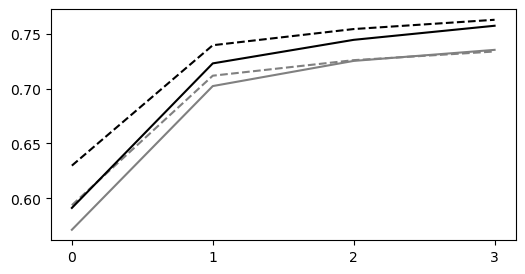

In [ ]:
all_depth_feve.shape
nmouse = len(mouse_ids)
varplot = np.zeros((nmouse, 2, 2, 4)) # mouse, area, layer
for i, mouse_id in enumerate(mouse_ids):
    for iarea in range(2):
        for ilayer in range(2):
            select = (mouse_id_all==mouse_id) & (areas_all==iarea) & (layers_all==ilayer+1)
            varplot[i, iarea, ilayer] = np.nanmean(all_depth_feve[:, select], axis=1) # (n_depth,)
fig, ax = plt.subplots(figsize=(6,3))
# v1 is solid and medial is dashed
# plot mean and sem
depth_colors = ['gray', 'black']
line_styles = ['solid', 'dashed']
for ilayer in range(2):
    for iarea in range(2):
        ax.plot(np.arange(4), np.nanmean(varplot[:, iarea, ilayer], axis=0), color=depth_colors[ilayer], linestyle=line_styles[iarea], label=f'{area_names[iarea]}, {layer_names[ilayer]}')
        # ax.fill_between(np.arange(4), np.nanmean(varplot[:, iarea, ilayer], axis=0)-np.nanstd(varplot[:, iarea, ilayer], axis=0)/np.sqrt(nmouse), np.nanmean(varplot[:, iarea, ilayer], axis=0)+np.nanstd(varplot[:, iarea, ilayer], axis=0)/np.sqrt(nmouse), color=depth_colors[ilayer], alpha=0.3)
ax.set_xticks(np.arange(4))

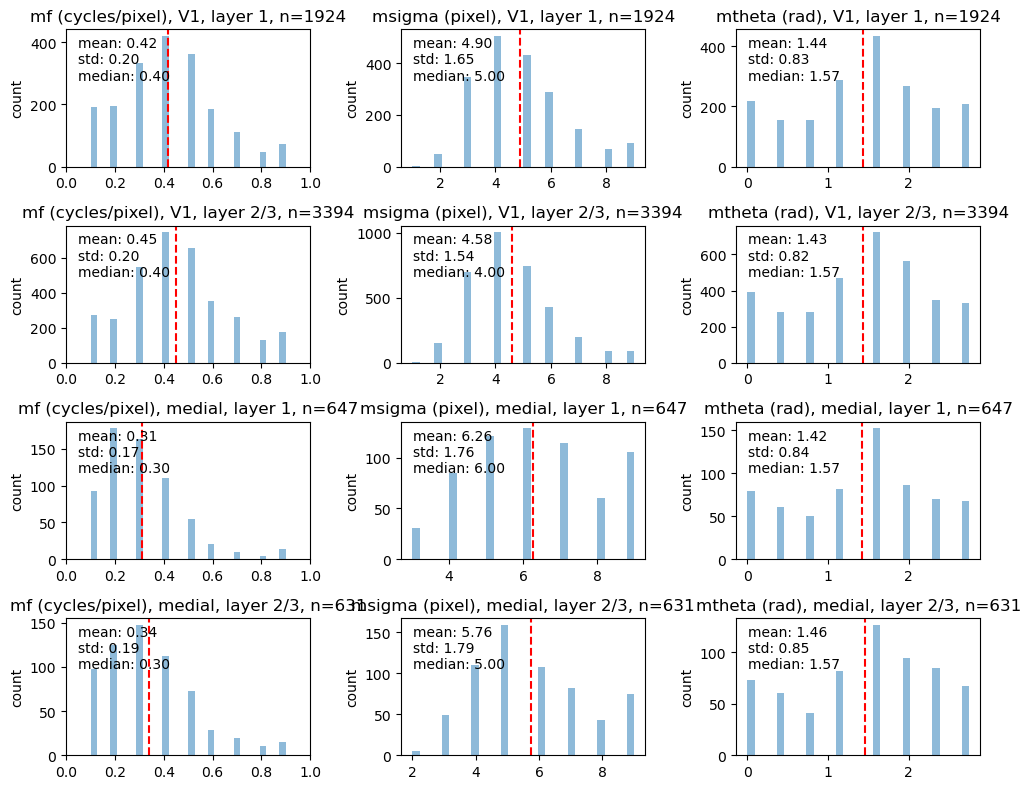

In [ ]:
fig, ax = plt.subplots(4, 3, figsize=(10,8))
gabor_mf = mf_all
gabor_msigma = msigma_all
gabor_mtheta = mtheta_all
vars = [gabor_mf, gabor_msigma, gabor_mtheta]
ilayers = layers_all
iareas = areas_all
var_names = ['mf (cycles/pixel)', 'msigma (pixel)', 'mtheta (rad)']
for i in range(3):
    var_plot = vars[i]
    var_name = var_names[i]
    for iarea in range(2):
        area_name = 'V1' if iarea==0 else 'medial'
        for ilayer in range(2):
            indexes = np.where((iareas == iarea) & (ilayers == (ilayer+1)))[0]
            layer_name = 'layer 1' if ilayer==0 else 'layer 2/3'
            ax[ilayer+iarea*2, i].hist(var_plot[indexes], bins=30, alpha=0.5)
            ax[ilayer+iarea*2, i].set_title(f'{var_name}, {area_name}, {layer_name}, n={len(indexes)}')
            mu = np.mean(var_plot[indexes])
            sd = np.std(var_plot[indexes])
            med = np.median(var_plot[indexes])
            ax[ilayer+iarea*2, i].axvline(mu, color='red', linestyle='--', label='mean')
            # add std band
            # ax[ilayer+iarea*2, i].axvspan(mu-sd, mu+sd, color='orange', alpha=0.3, label='std')
            # ax[i, ilayer+iarea*2].axvline(mu+sd, color='orange', linestyle='--', label='std')
            ax[ilayer+iarea*2, i].text(0.05, 0.95, f'mean: {mu:.2f}\nstd: {sd:.2f}\nmedian: {med:.2f}', transform=ax[ilayer+iarea*2, i].transAxes, fontsize=10, verticalalignment='top')
            if i==0: ax[ilayer+iarea*2, i].set_xlim([0, 1])
            # if i==1: ax[ilayer+iarea*2, i].set_xlim([0, 1])
            # if i==2: ax[ilayer+iarea*2, i].set_xlim([0, 40])
            ax[ilayer+iarea*2, i].set_ylabel('count')
plt.tight_layout()

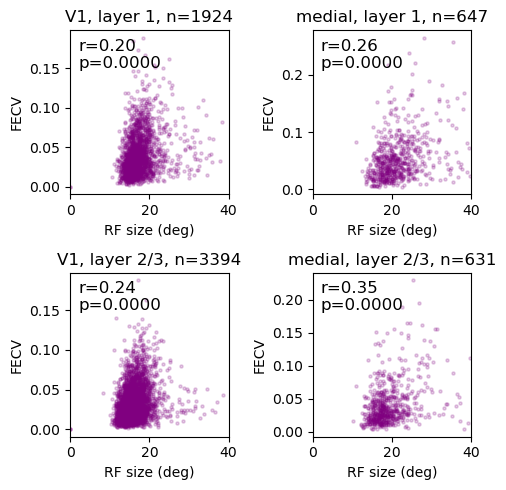

In [ ]:
# rfsize vs fecv for different layers and areas
fig, ax = plt.subplots(2, 2, figsize=(5,5))
fecv = fecv_all
rfsize = rfsize_all
iareas = areas_all
ilayers = layers_all
for iarea in range(2):
    for ilayer in range(2):
        ax_ = ax[ilayer, iarea]
        idxes = np.where((iareas==iarea) & (ilayers==(ilayer+1)))[0]
        ax_.scatter(rfsize[idxes], fecv[idxes], s=5, alpha=0.2, color='purple')
        ax_.set_title(f'{area_names[iarea]}, {layer_names[ilayer]}, n={len(idxes)}')
        # statistics
        from scipy import stats
        r, p = stats.pearsonr(rfsize[idxes], fecv[idxes])
        ax_.text(0.05, 0.95, f'r={r:.2f}\np={p:.4f}', transform=ax_.transAxes, fontsize=12, verticalalignment='top')
        ax_.set_xlabel('RF size (deg)')
        ax_.set_ylabel('FECV')
        ax_.set_xlim([0, 40])
# plt.suptitle(f'mouse {data.mouse_names[mouse_id]}_{data.exp_date[mouse_id]}')
plt.tight_layout()

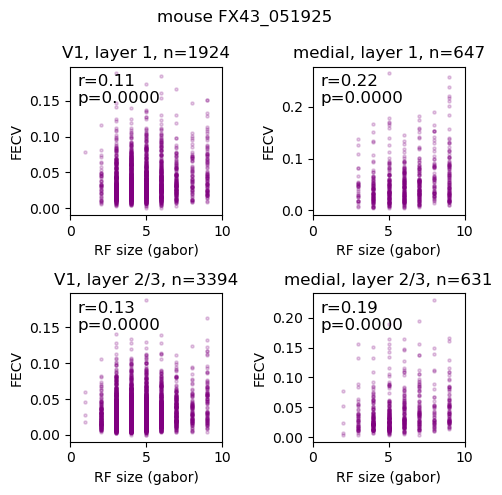

In [ ]:
# rfsize vs fecv for different layers and areas
fig, ax = plt.subplots(2, 2, figsize=(5,5))
fev = fecv_all
rfsize = msigma_all
iareas = areas_all
ilayers = layers_all
for iarea in range(2):
    for ilayer in range(2):
        ax_ = ax[ilayer, iarea]
        idxes = np.where((iareas==iarea) & (ilayers==(ilayer+1)))[0]
        ax_.scatter(rfsize[idxes], fev[idxes], s=5, alpha=0.2, color='purple')
        ax_.set_title(f'{area_names[iarea]}, {layer_names[ilayer]}, n={len(idxes)}')
        # statistics
        from scipy import stats
        r, p = stats.pearsonr(rfsize[idxes], fev[idxes])
        ax_.text(0.05, 0.95, f'r={r:.2f}\np={p:.4f}', transform=ax_.transAxes, fontsize=12, verticalalignment='top')
        ax_.set_xlabel('RF size (gabor)')
        ax_.set_ylabel('FECV')
        ax_.set_xlim([0, 10])
plt.suptitle(f'mouse {data.mouse_names[mouse_id]}_{data.exp_date[mouse_id]}')
plt.tight_layout()

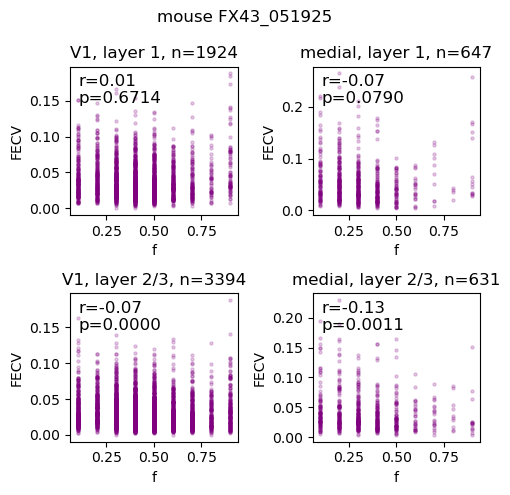

In [ ]:
# rfsize vs fecv for different layers and areas
fig, ax = plt.subplots(2, 2, figsize=(5,5))
fev = fecv_all
rfsize = rfsize_all
iareas = areas_all
ilayers = layers_all
for iarea in range(2):
    for ilayer in range(2):
        ax_ = ax[ilayer, iarea]
        idxes = np.where((iareas==iarea) & (ilayers==(ilayer+1)))[0]
        ax_.scatter(mf_all[idxes], fecv_all[idxes], s=5, alpha=0.2, color='purple')
        ax_.set_title(f'{area_names[iarea]}, {layer_names[ilayer]}, n={len(idxes)}')
        # statistics
        from scipy import stats
        r, p = stats.pearsonr(mf_all[idxes], fecv_all[idxes])
        ax_.text(0.05, 0.95, f'r={r:.2f}\np={p:.4f}', transform=ax_.transAxes, fontsize=12, verticalalignment='top')
        ax_.set_xlabel('f')
        ax_.set_ylabel('FECV')
        # ax_.set_xlim([0, 50])
        # ax_.set_ylim([0, 1.5])
plt.suptitle(f'mouse {data.mouse_names[mouse_id]}_{data.exp_date[mouse_id]}')
plt.tight_layout()

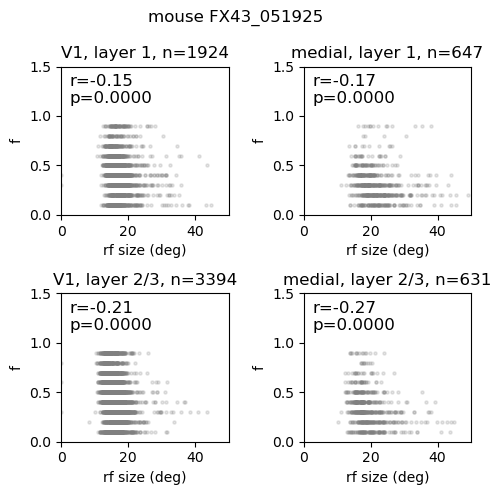

In [ ]:
# rfsize vs fecv for different layers and areas
fig, ax = plt.subplots(2, 2, figsize=(5,5))
fev = fecv_all
rfsize = rfsize_all
iareas = areas_all
ilayers = layers_all
for iarea in range(2):
    for ilayer in range(2):
        ax_ = ax[ilayer, iarea]
        idxes = np.where((iareas==iarea) & (ilayers==(ilayer+1)))[0]
        ax_.scatter(rfsize[idxes], mf_all[idxes], s=5, alpha=0.2, color='gray')
        ax_.set_title(f'{area_names[iarea]}, {layer_names[ilayer]}, n={len(idxes)}')
        # statistics
        from scipy import stats
        r, p = stats.pearsonr(rfsize[idxes], mf_all[idxes])
        ax_.text(0.05, 0.95, f'r={r:.2f}\np={p:.4f}', transform=ax_.transAxes, fontsize=12, verticalalignment='top')
        ax_.set_xlabel('rf size (deg)')
        ax_.set_ylabel('f')
        ax_.set_xlim([0, 50])
        ax_.set_ylim([0, 1.5])
plt.suptitle(f'mouse {data.mouse_names[mouse_id]}_{data.exp_date[mouse_id]}')
plt.tight_layout()

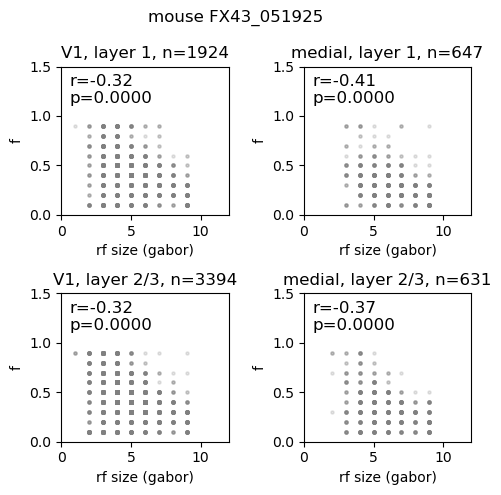

In [ ]:
# rfsize vs fecv for different layers and areas
fig, ax = plt.subplots(2, 2, figsize=(5,5))
fev = fecv_all
rfsize = msigma_all
iareas = areas_all
ilayers = layers_all
for iarea in range(2):
    for ilayer in range(2):
        ax_ = ax[ilayer, iarea]
        idxes = np.where((iareas==iarea) & (ilayers==(ilayer+1)))[0]
        ax_.scatter(rfsize[idxes], mf_all[idxes], s=5, alpha=0.2, color='gray')
        ax_.set_title(f'{area_names[iarea]}, {layer_names[ilayer]}, n={len(idxes)}')
        # statistics
        from scipy import stats
        r, p = stats.pearsonr(rfsize[idxes], mf_all[idxes])
        ax_.text(0.05, 0.95, f'r={r:.2f}\np={p:.4f}', transform=ax_.transAxes, fontsize=12, verticalalignment='top')
        ax_.set_xlabel('rf size (gabor)')
        ax_.set_ylabel('f')
        ax_.set_xlim([0, 12])
        ax_.set_ylim([0, 1.5])
plt.suptitle(f'mouse {data.mouse_names[mouse_id]}_{data.exp_date[mouse_id]}')
plt.tight_layout()

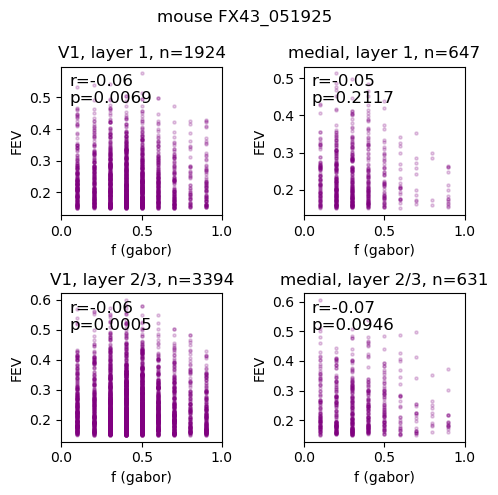

In [ ]:
# rfsize vs fecv for different layers and areas
fig, ax = plt.subplots(2, 2, figsize=(5,5))
fev = fev_all
rfsize = msigma_all
iareas = areas_all
ilayers = layers_all
for iarea in range(2):
    for ilayer in range(2):
        ax_ = ax[ilayer, iarea]
        idxes = np.where((iareas==iarea) & (ilayers==(ilayer+1)))[0]
        ax_.scatter(gabor_mf[idxes], fev[idxes], s=5, alpha=0.2, color='purple')
        ax_.set_title(f'{area_names[iarea]}, {layer_names[ilayer]}, n={len(idxes)}')
        # statistics
        from scipy import stats
        r, p = stats.pearsonr(gabor_mf[idxes], fev[idxes])
        ax_.text(0.05, 0.95, f'r={r:.2f}\np={p:.4f}', transform=ax_.transAxes, fontsize=12, verticalalignment='top')
        ax_.set_xlabel('f (gabor)')
        ax_.set_ylabel('FEV')
        ax_.set_xlim([0, 1])
plt.suptitle(f'mouse {data.mouse_names[mouse_id]}_{data.exp_date[mouse_id]}')
plt.tight_layout()

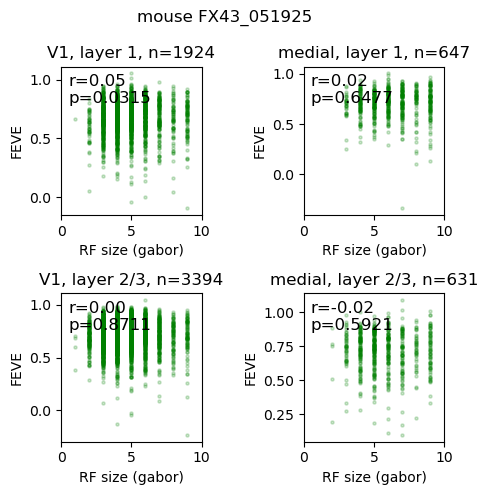

In [ ]:
# rfsize vs fecv for different layers and areas
fig, ax = plt.subplots(2, 2, figsize=(5,5))
feve = feve_all
rfsize = msigma_all
iareas = areas_all
ilayers = layers_all
for iarea in range(2):
    for ilayer in range(2):
        ax_ = ax[ilayer, iarea]
        idxes = np.where((iareas==iarea) & (ilayers==(ilayer+1)))[0]
        ax_.scatter(rfsize[idxes], feve[idxes], s=5, alpha=0.2, color='g')
        ax_.set_title(f'{area_names[iarea]}, {layer_names[ilayer]}, n={len(idxes)}')
        # statistics
        from scipy import stats
        r, p = stats.pearsonr(rfsize[idxes], feve[idxes])
        ax_.text(0.05, 0.95, f'r={r:.2f}\np={p:.4f}', transform=ax_.transAxes, fontsize=12, verticalalignment='top')
        ax_.set_xlabel('RF size (gabor)')
        ax_.set_ylabel('FEVE')
        ax_.set_xlim([0, 10])
plt.suptitle(f'mouse {data.mouse_names[mouse_id]}_{data.exp_date[mouse_id]}')
plt.tight_layout()

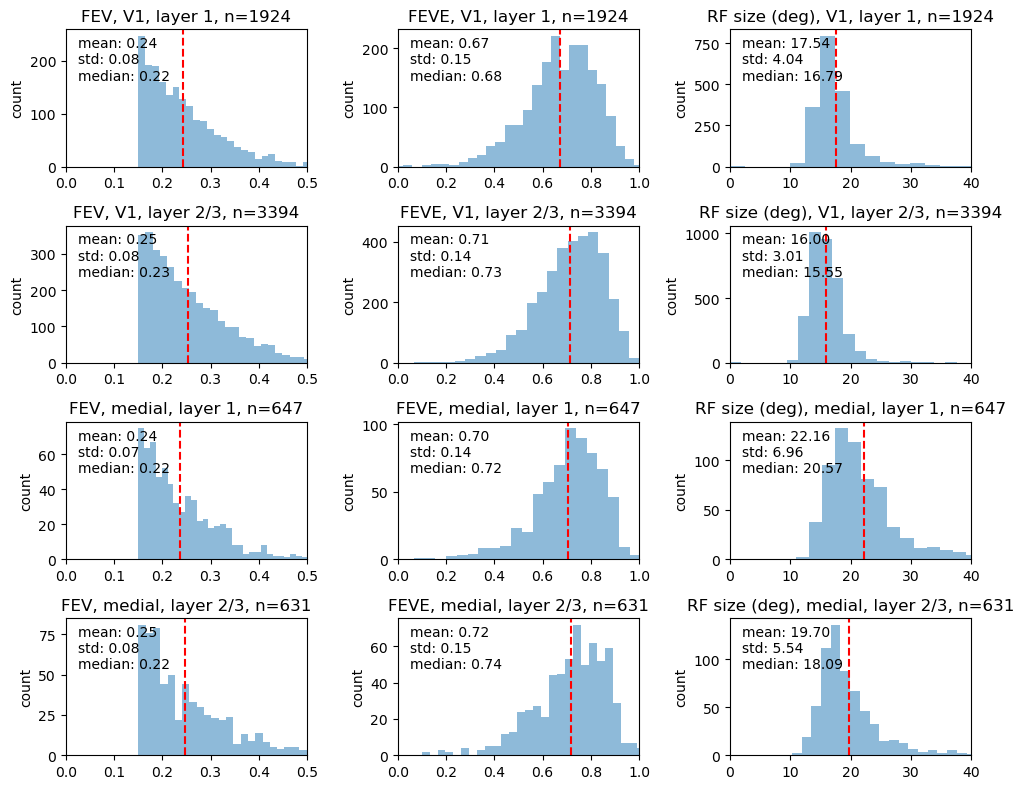

In [ ]:
fig, ax = plt.subplots(4, 3, figsize=(10,8))
vars = [fev_all, feve_all, rfsize_all]
var_names = ['FEV', 'FEVE', 'RF size (deg)']
for i in range(3):
    var_plot = vars[i]
    var_name = var_names[i]
    for iarea in range(2):
        area_name = 'V1' if iarea==0 else 'medial'
        for ilayer in range(2):
            # indexes = idxes[res_dict['ilayer'][idxes]==(ilayer+1)]
            indexes = np.where((areas_all==iarea) & (layers_all==(ilayer+1)))[0]
            layer_name = 'layer 1' if ilayer==0 else 'layer 2/3'
            ax[ilayer+iarea*2, i].hist(var_plot[indexes], bins=30, alpha=0.5)
            ax[ilayer+iarea*2, i].set_title(f'{var_name}, {area_name}, {layer_name}, n={len(indexes)}')
            mu = np.mean(var_plot[indexes])
            sd = np.std(var_plot[indexes])
            med = np.median(var_plot[indexes])
            ax[ilayer+iarea*2, i].axvline(mu, color='red', linestyle='--', label='mean')
            # ax[i, ilayer+iarea*2].axvline(mu+sd, color='orange', linestyle='--', label='std')
            ax[ilayer+iarea*2, i].text(0.05, 0.95, f'mean: {mu:.2f}\nstd: {sd:.2f}\nmedian: {med:.2f}', transform=ax[ilayer+iarea*2, i].transAxes, fontsize=10, verticalalignment='top')
            if i==0: ax[ilayer+iarea*2, i].set_xlim([0, 0.5])
            if i==1: ax[ilayer+iarea*2, i].set_xlim([0, 1])
            if i==2: ax[ilayer+iarea*2, i].set_xlim([0, 40])
            ax[ilayer+iarea*2, i].set_ylabel('count')
plt.tight_layout()

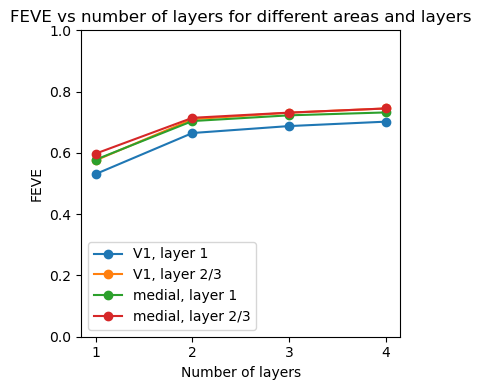

In [ ]:
# plot all depth feve with different areas and layers
fig, ax = plt.subplots(1, 1, figsize=(4,4))
n_depth = all_depth_feve.shape[0]
depths = np.arange(1, n_depth+1)
for iarea in range(2):
    area_name = 'V1' if iarea==0 else 'medial'
    for ilayer in range(2):
        indexes = np.where((areas_all==iarea) & (layers_all==(ilayer+1)))[0]
        layer_name = 'layer 1' if ilayer==0 else 'layer 2/3'
        feve_mean = np.mean(all_depth_feve[:, indexes], axis=1)
        ax.plot(depths, feve_mean, marker='o', label=f'{area_name}, {layer_name}')
ax.set_xlabel('Number of layers')
ax.set_ylabel('FEVE')
ax.set_title('FEVE vs number of layers for different areas and layers')
ax.set_xticks(depths)
ax.set_ylim([0, 1])
ax.legend()
plt.tight_layout()